In [1]:
!pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached numba-0.65.1-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl.metadata (18 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.1.0-cp311-cp311-win_amd64.whl.metadata (5.8 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached numba-0.65.1-cp311-cp311-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl (38.1 MB)
Using cached pooch-1.9.0-py3-none-any.whl (67 kB)
Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached soxr-1.1.0-cp311-cp311-win_amd6

In [8]:
import librosa

audio , sr = librosa.load('speech.wav',
                          sr=16000
                          ) # sr = sample rate , audio is a numpy array of audio samples

In [9]:
audio #converted to numpy array

array([ 1.5941412e-06, -1.0580344e-05, -3.1768564e-06, ...,
       -1.9331981e-03, -1.8884516e-03,  0.0000000e+00],
      shape=(293700,), dtype=float32)

In [10]:
sr #sample rate

16000

In [11]:
len(audio)

293700

In [12]:
duration = len(audio)/sr
duration

18.35625

In [13]:
audio[:10]

array([ 1.5941412e-06, -1.0580344e-05, -3.1768564e-06,  3.7759678e-06,
       -1.1132073e-05, -3.5989215e-06,  1.8016516e-06,  5.2935120e-06,
       -9.5587839e-06, -7.9340798e-06], dtype=float32)

***visualize waveform***

In [14]:
import librosa.display
import matplotlib.pyplot as plt

In [19]:
plt.figure(figsize=(10,4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

Text(21.722222222222214, 0.5, 'Amplitude')

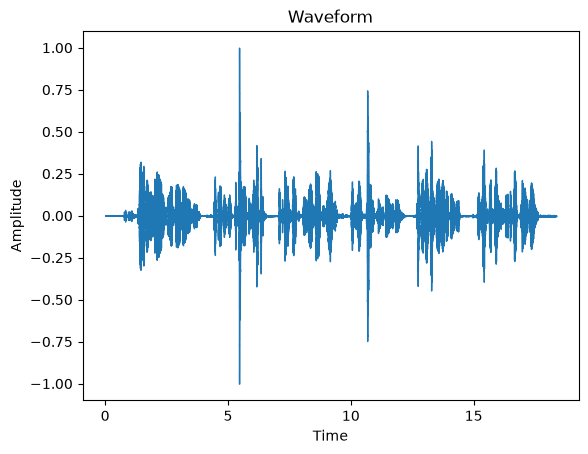

In [21]:
librosa.display.waveshow(
    audio,
    sr=sr
)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

In [24]:
mfccs = librosa.feature.mfcc(
    y = audio,
    sr = sr,
    n_mfcc = 13 #first 13 coefficients - most important features
)

#internally the audio->stft->mel filter bank -> log -> dct -> MFCC flow is performed 

In [25]:
mfccs.shape

(13, 574)

***13 coefficients and 574 time frames***

In [26]:
mfccs

array([[-499.4226   , -499.4226   , -499.4226   , ..., -475.8177   ,
        -476.78848  , -479.9948   ],
       [   0.       ,    0.       ,    0.       , ...,   30.006676 ,
          29.217102 ,   25.626251 ],
       [   0.       ,    0.       ,    0.       , ...,   22.83083  ,
          23.269627 ,   21.33263  ],
       ...,
       [   0.       ,    0.       ,    0.       , ...,    3.148953 ,
           2.360626 ,    3.7482157],
       [   0.       ,    0.       ,    0.       , ...,    3.4230194,
           2.4016037,    2.9267037],
       [   0.       ,    0.       ,    0.       , ...,    3.18288  ,
           2.2513578,    1.3915915]], shape=(13, 574), dtype=float32)

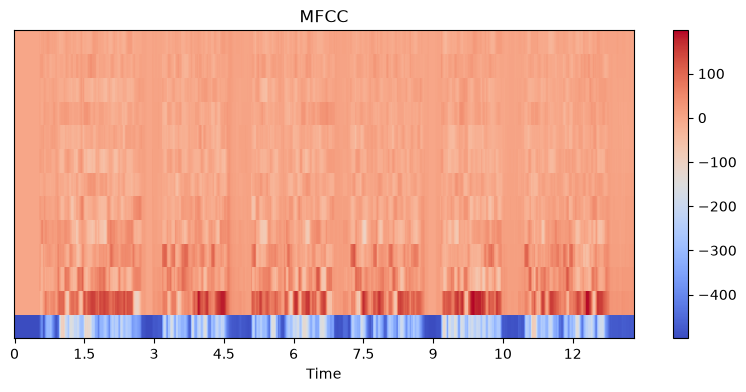

In [27]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfccs,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC")

plt.show()